In [ ]:
from google.colab import drive, files
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
# ===== RF + 標準化 訓練程式 =====
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# === 1. 讀取資料 ===
CSV_PATH = "/content/drive/MyDrive/BL0909/M/ALL.csv"
# === 1. 讀取資料 ===
data = pd.read_csv(CSV_PATH)

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# === ⭐ 2. 加入 B+3 特徵 ===
mean_feat = np.mean(X, axis=1, keepdims=True)
max_feat  = np.max(X, axis=1, keepdims=True)
std_feat  = np.std(X, axis=1, keepdims=True)

X = np.hstack([X, mean_feat, max_feat, std_feat])

print("加入B+3後 shape:", X.shape)  # 👉 應該變成 1235

# === 3. Label Encoding ===
le = LabelEncoder()
y = le.fit_transform(y)

# === 4. train/test split ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# === 5. RF Pipeline ===
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

# === 6. 訓練 ===
pipe.fit(X_train, y_train)

# === 7. 評估 ===
y_pred = pipe.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred)

print("Accuracy =", acc)
print("Accuracy (10位小數) =", f"{acc:.10f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
# === 8. 儲存模型與 LabelEncoder ===
MODEL_PATH = "/content/drive/MyDrive/BL0909/M/RF_B+3_scaled.joblib"
ENCODER_PATH = "/content/drive/MyDrive/BL0909/M/label_encoder.joblib"

joblib.dump(pipe, MODEL_PATH)
joblib.dump(le, ENCODER_PATH)

print(f"✅ 模型已儲存: {MODEL_PATH}")
print(f"✅ LabelEncoder已儲存: {ENCODER_PATH}")


加入B+3後 shape: (71808, 1235)
Accuracy = 0.9940119760479041
Accuracy (10位小數) = 0.9940119760
Confusion Matrix:
[[3542   49    0    0]
 [  28 3553    9    0]
 [   0    0 3591    0]
 [   0    0    0 3590]]

Classification Report:
              precision    recall  f1-score   support

          BG       0.99      0.99      0.99      3591
         PET       0.99      0.99      0.99      3590
          PP       1.00      1.00      1.00      3591
          PS       1.00      1.00      1.00      3590

    accuracy                           0.99     14362
   macro avg       0.99      0.99      0.99     14362
weighted avg       0.99      0.99      0.99     14362

✅ 模型已儲存: /content/drive/MyDrive/BL0909/M/RF_B+3_scaled.joblib
✅ LabelEncoder已儲存: /content/drive/MyDrive/BL0909/M/label_encoder.joblib


In [ ]:
train_df = pd.DataFrame(X_train)
test_df = pd.DataFrame(X_test)

common = pd.merge(train_df, test_df, how='inner')

print("train-test overlap:", len(common))

train-test overlap: 0


Accuracy: 0.99401198

Classification Report:
              precision    recall  f1-score   support

          BL     0.9922    0.9864    0.9892      3591
         PET     0.9864    0.9897    0.9880      3590
          PP     0.9975    1.0000    0.9987      3591
          PS     1.0000    1.0000    1.0000      3590

    accuracy                         0.9940     14362
   macro avg     0.9940    0.9940    0.9940     14362
weighted avg     0.9940    0.9940    0.9940     14362


Confusion Matrix:
[[3542   49    0    0]
 [  28 3553    9    0]
 [   0    0 3591    0]
 [   0    0    0 3590]]


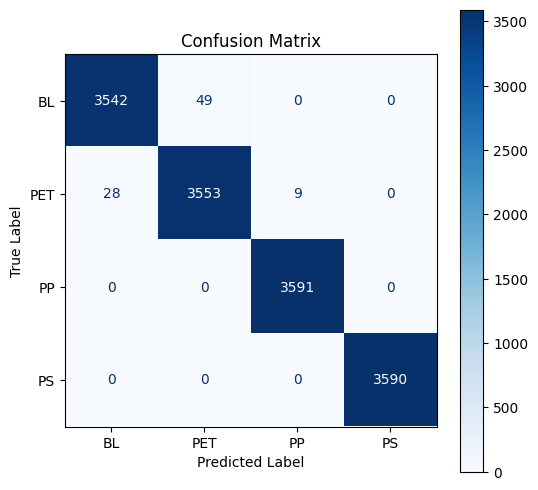

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

LABELS = ["BL", "PET", "PP", "PS"]

# ===== 測試集預測 =====
y_pred = pipe.predict(X_test)

# ===== 真實標籤 =====
y_true = y_test

# ===== 準確率 =====
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.8f}")

# ===== 分類報告 =====
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=LABELS, digits=4))

# ===== 混淆矩陣 =====
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=True)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

BANDS = 1232
pipe 期望特徵數 = 1235
rf.classes_ = [0 1 2 3]
rf.classes_ → colors: {0: ('0', (50, 50, 50)), 1: ('1', (255, 0, 0)), 2: ('2', (0, 0, 255)), 3: ('3', (0, 255, 0))}
✅ Saved: /content/drive/MyDrive/0909gr/M/RF_Bplus3_Recon_20260406_060830.jpg


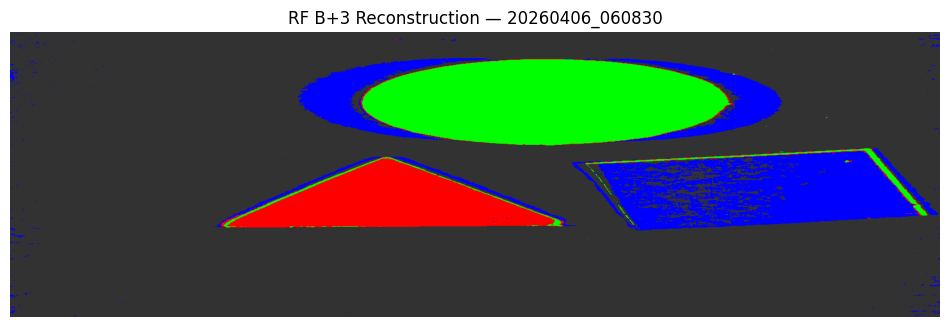

In [ ]:
# ===== 讓 RF 上色與 MLP/Conv1D 一樣 =====
import os, glob
import numpy as np
import pandas as pd
import cv2, joblib
from datetime import datetime
import matplotlib.pyplot as plt

# 固定路徑
CSV_PATH   = "/content/drive/MyDrive/BL0909/M/ALL.csv"
OUT_DIR    = "/content/drive/MyDrive/0909gr/M"
IMAGE_DIR  = "/content/drive/MyDrive/0909gr/GR"
MODEL_PATH = "/content/drive/MyDrive/0909gr/M/RF_B+3_scaled.joblib"

os.makedirs(OUT_DIR, exist_ok=True)

# 1) 載入 RF pipeline
pipe = joblib.load(MODEL_PATH)
rf   = pipe.named_steps["rf"]

# 2) 取 BANDS 做一致性檢查
BANDS = len(pd.read_csv(CSV_PATH, nrows=1).columns) - 1

first_imgs = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.jpg")))
assert first_imgs, f"資料夾 {IMAGE_DIR} 找不到 JPG"

h0, w0 = cv2.imread(first_imgs[0], 0).shape
assert h0 == BANDS, f"影像高度 {h0} 與 CSV bands {BANDS} 不符"

print("BANDS =", BANDS)
print("pipe 期望特徵數 =", pipe.named_steps["scaler"].n_features_in_)
print("rf.classes_ =", rf.classes_)

# ===== 固定標籤與顏色 =====
COLOR_MAP = {
      "BG":  (50, 50, 50),  # 白
        "PET": (255,   0,   0),  # 藍 (BGR)
        "PS":  (  0, 255,   0),  # 綠
        "PP":  (  0,   0, 255),     # 紅色(BGR)
}

ALIASES = {
    "BACKGROUND": "BG",
    "bg": "BG",
    "BG": "BG",
    "pet": "PET",
    "PET": "PET",
    "pp": "PP",
    "PP": "PP",
    "ps": "PS",
    "PS": "PS",
    "0": "BG",
    "1": "PET",
    "2": "PP",
    "3": "PS"
}

def canon_name(name):
    k = str(name).strip()
    return ALIASES.get(k, ALIASES.get(k.upper(), k.upper()))

# 依 rf.classes_ 建立 index -> color
index_to_color = {}
for i, cls in enumerate(rf.classes_):
    cname = canon_name(cls)
    index_to_color[i] = COLOR_MAP.get(cname, (128, 128, 128))

print("rf.classes_ → colors:",
      {i: (str(rf.classes_[i]), tuple(index_to_color[i])) for i in range(len(rf.classes_))})

def predict_gray_with_pipeline(gray_u8: np.ndarray) -> np.ndarray:
    """
    gray_u8: shape = (BANDS, W)
    回傳: probs, shape = (W, n_classes)
    """
    H, W = gray_u8.shape
    assert H == BANDS, f"影像高度 {H} != BANDS {BANDS}"

    # 每一欄是一筆光譜，轉成每列一筆樣本
    X = gray_u8.T.astype(np.float32)   # (W, 1232)

    # ===== 加入 B+3 =====
    mean_feat = np.mean(X, axis=1, keepdims=True)
    max_feat  = np.max(X, axis=1, keepdims=True)
    std_feat  = np.std(X, axis=1, keepdims=True)

    X = np.hstack([X, mean_feat, max_feat, std_feat])   # (W, 1235)

    # 檢查維度
    expected_dim = pipe.named_steps["scaler"].n_features_in_
    assert X.shape[1] == expected_dim, f"現在特徵數 {X.shape[1]}，但模型需要 {expected_dim}"

    probs = pipe.predict_proba(X)
    return probs

def color_row_from_pred(pred_idx, index_to_color):
    row = np.vstack([np.array(index_to_color[int(c)], dtype=np.uint8) for c in pred_idx])
    return row[np.newaxis, :, :]   # (1, W, 3)

# 5) 跑全部 JPG 並輸出
img_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.jpg")))
tiles = []

for p in img_paths:
    g = cv2.imread(p, 0)
    if g is None:
        print("讀不到影像：", p)
        continue

    probs = predict_gray_with_pipeline(g)
    pred  = np.argmax(probs, axis=1)
    tiles.append(color_row_from_pred(pred, index_to_color))

# 6) 存圖 & 顯示
if tiles:
    recon = np.vstack(tiles)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_img = os.path.join(OUT_DIR, f"RF_Bplus3_Recon_{ts}.jpg")
    cv2.imwrite(out_img, recon)
    print("✅ Saved:", out_img)

    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(recon, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"RF B+3 Reconstruction — {ts}")
    plt.show()
else:
    print("No tiles generated.")
